In [1]:
import sys
sys.path.append('..')
import numpy as np
import pickle 
from delta_temp.tcrit import TCRIT, Tcrit_map, data_both_biomes
import matplotlib.pyplot as plt
from utils import d_sl, years, dense_vegetation, sl_tropics
from sklearn.linear_model import LinearRegression

from matplotlib import colors
import matplotlib.ticker as mticker
import rasterio as rio
from scipy.stats import skew
from tqdm import tqdm
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colormaps

terra = rio.open("/data/gaston/ecostress/ecostress/terraaqua.tif", 'r').read(1)
d_ext = {"South America": "south_america",  "Africa": "africa", "SE Asia": "south_east_asia"}
d_ext = {value: key for key, value in d_ext.items()}

In [3]:
mask = np.zeros_like(data_both_biomes).astype(float)
mask[:,:] = np.nan
for key, sl in d_sl.items():
    ext = key
        
    lr_outfile = f"/data/gaston/ecostress/ecostress/worldwide/delta_Tmin_Tmodis{ext}_per_year_2001_2020_reversed_tminv6.npy" # _reversed _tminv5
    lr_map = - np.load(lr_outfile)[...,-1]
    lr_map[~data_both_biomes[sl]] = np.nan
    lr_map[~dense_vegetation[sl]] = np.nan
    mask[sl] = lr_map
final_map =  mask[sl_tropics]

-16 37


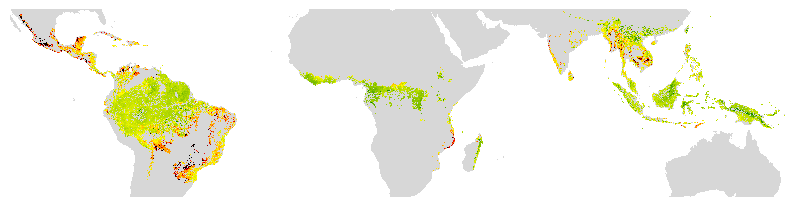

In [8]:


import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import AxesGrid

def shiftedColorMap(cmap, start=0, midpoint=0.5, stop=1.0, name='shiftedcmap'):
    '''
    Function to offset the "center" of a colormap. Useful for
    data with a negative min and positive max and you want the
    middle of the colormap's dynamic range to be at zero.

    Input
    -----
      cmap : The matplotlib colormap to be altered
      start : Offset from lowest point in the colormap's range.
          Defaults to 0.0 (no lower offset). Should be between
          0.0 and `midpoint`.
      midpoint : The new center of the colormap. Defaults to 
          0.5 (no shift). Should be between 0.0 and 1.0. In
          general, this should be  1 - vmax / (vmax + abs(vmin))
          For example if your data range from -15.0 to +5.0 and
          you want the center of the colormap at 0.0, `midpoint`
          should be set to  1 - 5/(5 + 15)) or 0.75
      stop : Offset from highest point in the colormap's range.
          Defaults to 1.0 (no upper offset). Should be between
          `midpoint` and 1.0.
    '''
    cdict = {
        'red': [],
        'green': [],
        'blue': [],
        'alpha': []
    }

    # regular index to compute the colors
    reg_index = np.linspace(start, stop, 257)

    # shifted index to match the data
    shift_index = np.hstack([
        np.linspace(0.0, midpoint, 128, endpoint=False), 
        np.linspace(midpoint, 1.0, 129, endpoint=True)
    ])

    for ri, si in zip(reg_index, shift_index):
        r, g, b, a = cmap(ri)

        cdict['red'].append((si, r, r))
        cdict['green'].append((si, g, g))
        cdict['blue'].append((si, b, b))
        cdict['alpha'].append((si, a, a))

    newcmap = matplotlib.colors.LinearSegmentedColormap(name, cdict)
    # plt.register_cmap(cmap=newcmap)

    return newcmap


from matplotlib import colors
def make_fig_(data_species, figsize=(10,5), minn=0, maxx=0,sl=None, interpolation="none", title_fig=None, is_hansen=False, cmap_='brg',save_title=None):
    fig = plt.figure(figsize=figsize)
    ax = fig.gca()
    cmap_terra = colors.ListedColormap(['white', '#D7D7D7FF']) #'grey'])
    img = terra[sl].squeeze()
    ax.imshow(img, cmap=cmap_terra)
    cmap_species = cmap_
    # cmap_species.set_under('k', alpha=0)
    cmap_species.set_bad(alpha=0)
    d = data_species.squeeze().copy()
    im = ax.imshow(d, cmap=cmap_species, interpolation=interpolation) # , norm=colors.LogNorm()
    min_cbar = int(np.nanmin(d)) 
    max_species = int(np.nanmax(d))
    print(min_cbar, max_species)
    min_cbar = minn
    max_species = maxx
    im.set_clim(min_cbar, max_species)
    ax.set_axis_off()
        
cmap_final = colormaps["hot"] # Reds_r
colors_ = [(0, 0, 0), (1, 0, 0), (1, 1, 0), (0, 0.5, 0)]   # Black -> Red -> Yellow -> Green -> White , (1, 1, 0)
n_bins = 100  # Discretizes the interpolation into bins
cmap_final = LinearSegmentedColormap.from_list('custom_hot', colors_, N=n_bins)
minn = -5
maxx = 25
midpoint=(-minn)/(maxx - minn)
cmap_final = shiftedColorMap(cmap_final, midpoint=midpoint, name='shifted')
make_fig_(final_map, interpolation='none', sl=sl_tropics, cmap_=cmap_final, minn=minn, maxx=maxx)

In [10]:
mask = np.zeros_like(data_both_biomes).astype(float)
mask[:,:] = np.nan
for key, sl in d_sl.items():
    ext = key
    lr_outfile = f"/data/gaston/ecostress/ecostress/worldwide/LinearRegression_delta_Tmin_Tmodis{ext}_per_year_2001_2020_tminv6.npy" # _reversed _tminv5
    lr_map = - np.load(lr_outfile)
    lr_map[~data_both_biomes[sl]] = np.nan
    lr_map[~dense_vegetation[sl]] = np.nan
    mask[sl] = lr_map

Text(0, 0.5, 'TSM slope 2001-2020')

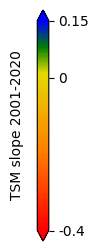

In [11]:
fig2 = plt.figure(figsize=(2, 3))
ax2 = fig2.gca()
rng = np.random.default_rng(seed=19680801)
data = rng.standard_normal((250, 250))

colors_ = [(1, 0, 0), (1,0.5,0), (0.9, 0.85, 0), (0, 0.5, 0), (0,0,1)]  # Black -> Red -> Yellow -> Green -> White , ,  (.9, .85, 0)
n_bins = 100  # Discretizes the interpolation into bins
cmap_species = LinearSegmentedColormap.from_list('custom', colors_, N=n_bins)
cmap_species = shiftedColorMap(cmap_species, midpoint=0.75, name='shifted')

min_cbar = -0.4
max_cbar = 0.15

# cmap_species = LinearSegmentedColormap.from_list("custom_cmap", ["red", 'orange', 'grey', "green", 'blue'])

im2 = ax2.imshow(data, cmap=cmap_species, vmin=min_cbar, vmax=max_cbar)

im2.set_clim(min_cbar, max_cbar)
im2.set_visible(False)
cbar2 = fig2.colorbar(im2,
                    ticks=[min_cbar, 0, max_cbar],
                    format=mticker.FixedFormatter([f'{min_cbar}', '0', f'{max_cbar}']),
                    extend='both'
                    )
ax2.remove()
cbar2.ax.set_ylabel('TSM slope 2001-2020', rotation=90, labelpad=-47, va='bottom')

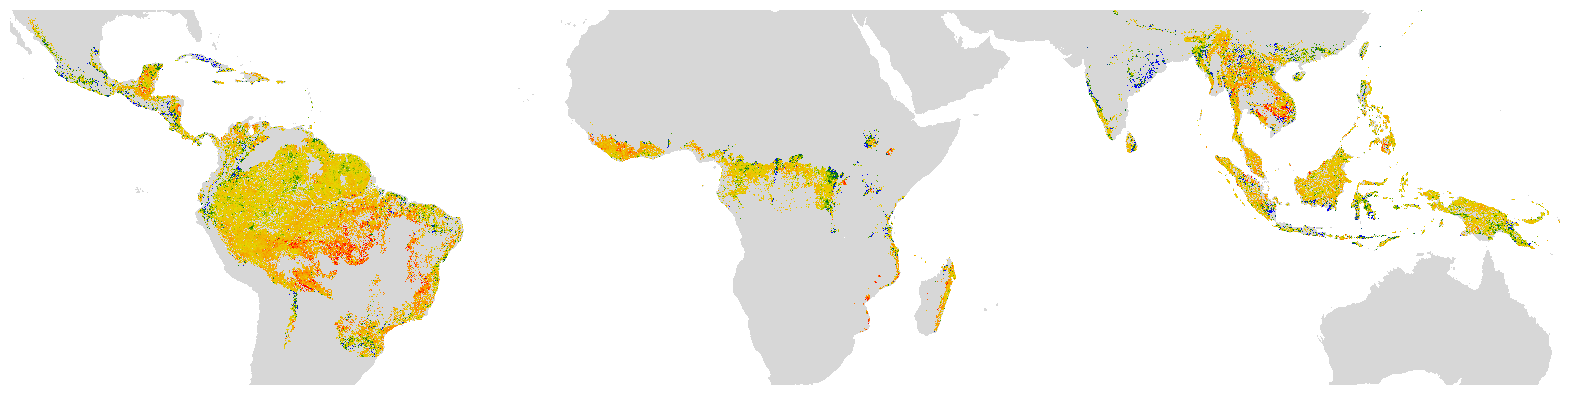

In [13]:

lr_map = mask
sl = sl_tropics
lr_map = lr_map[sl]
cmap_terra = colors.ListedColormap(['white', '#D7D7D7FF']) 

fig = plt.figure(figsize=(20,10))
ax = fig.gca()

img = terra[sl].squeeze()
ax.imshow(img, cmap=cmap_terra)


im = ax.imshow(lr_map, cmap=cmap_species, interpolation='none')
im.set_clim(min_cbar, max_cbar)

ax.set_axis_off()